In [781]:
##########################################################################################################################
### The code is used to conduct statistical comparison between 2 sets of data via A12 statistic for COMPILABILITY RATE ###
##########################################################################################################################

In [782]:
import pandas as pd
import pingouin as pg
from typing import Dict
from common import (
    filter_out_failed_iterations,
    filter_out_projects_within_list,
    prettify_prompt_name,

    calculate_pvalue_and_A12,
    build_comparison_boxplot,
    count_iterations_with_compilable_test_cases,
    threshold_projects_on_compilable_iterations,
)

In [783]:
# Set display options to show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# Convert DataFrame to a string with no truncation
pd.set_option('display.max_colwidth', None)

In [784]:
#########################################################
### Filepaths to the generated CSV data               ###
### Required columns for the datasets' CSV file:      ###
###    1. build_id,                                   ###
###    2. cut_quialified_name,                        ###
###    3. iteration,                                  ###
###    4. prompt_id,                                  ###
###    4. lines_covered,                              ###
###    5. lines_total,                                ###
###    6. branches_covered,                           ###
###    7. branches_total,                             ###
###    8. compilable_test_cases,                      ###
###    9. total_test_cases                            ###
#########################################################

#### input CSV data filepaths & output CSV data filepaths ####

csv_filename = "results.csv" # "testspark-coverage-results.csv"
output_compilability_filename = "testspark_compilability_rate.csv" # "compilability_rate.csv"
output_mean_compilability_filename = "testspark_mean_compilability_rate.csv" # "mean_compilability_rate.csv"


#### NOTES ####
# 1. RQ1 = "CUT"
# 1. RQ2 = "METHODS_DECLARATION" / DECL
# 1. config-1 = config-I = "5 iterations"
# 2. config-2 = config-II = "1 iteration"

#### RQ1:
### GPT-4 ###
# 1. RQ1-config-1 VS RQ1-config-2
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/GPT-4/config-I/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/GPT-4/config-II/TestSpark/{csv_filename}"
# model = "GPT-4"
# prompt_id_A = "CUT-5"
# prompt_id_B = "CUT-1"

# 2. RQ2-config-1 VS RQ2-config-2
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2/GPT-4/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2-config-II/GPT-4/TestSpark/{csv_filename}"
# model = "GPT-4"
# prompt_id_A = "DECLARATIONS-5"
# prompt_id_B = "DECLARATIONS-1"

### Llama-3.1-70B-Instruct ###
# 1. RQ1-config-1 VS RQ1-config-2
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/Llama-31-70B-Instruct/config-I/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/Llama-31-70B-Instruct/config-II/TestSpark/{csv_filename}"
# model = "Llama-3.1-70B-Instruct"
# prompt_id_A = "CUT-5"
# prompt_id_B = "CUT-1"

# 2. RQ2-config-1 VS RQ2-config-2
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2/Llama-31-70B-Instruct/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2-config-II/Llama-31-70B-Instruct/TestSpark/{csv_filename}"
# model = "Llama-3.1-70B-Instruct"
# prompt_id_A = "DECLARATIONS-5"
# prompt_id_B = "DECLARATIONS-1"


### Llama-3.1-8B-Instruct ###
# 1. RQ1-config-1 VS RQ1-config-2
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/Llama-31-8B-Instruct/config-I/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/Llama-31-8B-Instruct/config-II/TestSpark/{csv_filename}"
# model = "Llama-3.1-8B-Instruct"
# prompt_id_A = "CUT-5"
# prompt_id_B = "CUT-1"

# 2. RQ2-config-1 VS RQ2-config-2
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2/Llama-31-8B-Instruct/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2-config-II/Llama-31-8B-Instruct/TestSpark/{csv_filename}"
# model = "Llama-3.1-8B-Instruct"
# prompt_id_A = "DECLARATIONS-5"
# prompt_id_B = "DECLARATIONS-1"


### Llama-3.2-3B-Instruct ###
# 1. RQ1-config-1 VS RQ1-config-2
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/Llama-32-3B-Instruct/config-I/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/Llama-32-3B-Instruct/config-II/TestSpark/{csv_filename}"
# model = "Llama-3.2-3B-Instruct"
# prompt_id_A = "CUT-5"
# prompt_id_B = "CUT-1"

# 2. RQ2-config-1 VS RQ2-config-2
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2/Llama-32-3B-Instruct/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2-config-II/Llama-32-3B-Instruct/TestSpark/{csv_filename}"
# model = "Llama-3.2-3B-Instruct"
# prompt_id_A = "DECLARATIONS-5"
# prompt_id_B = "DECLARATIONS-1"


### Llama-3.2-1B-Instruct ###
# 1. RQ1-config-1 VS RQ1-config-2 | NOTE: ERROR: NO OBJECTS TO CONCATENATE
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/Llama-32-1B-Instruct/config-I/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/Llama-32-1B-Instruct/config-II/TestSpark/{csv_filename}"
# model = "Llama-3.2-1B-Instruct"
# prompt_id_A = "CUT-5"
# prompt_id_B = "CUT-1"

# 2. RQ2-config-1 VS RQ2-config-2 | NOTE: ERROR: NO OBJECTS TO CONCATENATE
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2/Llama-32-1B-Instruct/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2-config-II/Llama-32-1B-Instruct/TestSpark/{csv_filename}"
# model = "Llama-3.2-1B-Instruct"
# prompt_id_A = "DECLARATIONS-5"
# prompt_id_B = "DECLARATIONS-1"



#### RQ2:
### GPT-4 ###
# 1. RQ1-config-1 VS RQ2-config-1
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/GPT-4/config-I/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2/GPT-4/TestSpark/{csv_filename}"
# model = "GPT-4"
# prompt_id_A = "CUT-5"
# prompt_id_B = "DECLARATIONS-5"

# 2. RQ1-config-2 VS RQ2-config-2
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/GPT-4/config-II/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2-config-II/GPT-4/TestSpark/{csv_filename}"
# model = "GPT-4"
# prompt_id_A = "CUT-1"
# prompt_id_B = "DECLARATIONS-1"


### Llama-3.1-70B-Instruct ###
# 1. RQ1-config-1 VS RQ2-config-1
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/Llama-31-70B-Instruct/config-I/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2/Llama-31-70B-Instruct/TestSpark/{csv_filename}"
# model = "Llama-3.1-70B-Instruct"
# prompt_id_A = "CUT-5"
# prompt_id_B = "DECLARATIONS-5"

# 2. RQ1-config-2 VS RQ2-config-2
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/Llama-31-70B-Instruct/config-II/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2-config-II/Llama-31-70B-Instruct/TestSpark/{csv_filename}"
# model = "Llama-3.1-70B-Instruct"
# prompt_id_A = "CUT-1"
# prompt_id_B = "DECLARATIONS-1"


#### Llama-3.1-8B-Instruct ###
# 1. RQ1-config-1 VS RQ2-config-1
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/Llama-31-8B-Instruct/config-I/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2/Llama-31-8B-Instruct/TestSpark/{csv_filename}"
# model = "Llama-3.1-8B-Instruct"
# prompt_id_A = "CUT-5"
# prompt_id_B = "DECLARATIONS-5"

# 2. RQ1-config-2 VS RQ2-config-2
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/Llama-31-8B-Instruct/config-II/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2-config-II/Llama-31-8B-Instruct/TestSpark/{csv_filename}"
# model = "Llama-3.1-8B-Instruct"
# prompt_id_A = "CUT-1"
# prompt_id_B = "DECLARATIONS-1"


#### Llama-3.2-3B-Instruct ###
# 1. RQ1-config-1 VS RQ2-config-1
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/Llama-32-3B-Instruct/config-I/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2/Llama-32-3B-Instruct/TestSpark/{csv_filename}"
# model = "Llama-3.2-3B-Instruct"
# prompt_id_A = "CUT-5"
# prompt_id_B = "DECLARATIONS-5"

# 2. RQ1-config-2 VS RQ2-config-2
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/Llama-32-3B-Instruct/config-II/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2-config-II/Llama-32-3B-Instruct/TestSpark/{csv_filename}"
# model = "Llama-3.2-3B-Instruct"
# prompt_id_A = "CUT-1"
# prompt_id_B = "DECLARATIONS-1"


#### Llama-3.2-1B-Instruct ###
# 1. RQ1-config-1 VS RQ2-config-1
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/Llama-32-1B-Instruct/config-I/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2/Llama-32-1B-Instruct/TestSpark/{csv_filename}"
# model = "Llama-3.2-1B-Instruct"
# prompt_id_A = "CUT-5"
# prompt_id_B = "DECLARATIONS-5"

# 2. RQ1-config-2 VS RQ2-config-2
# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/Llama-32-1B-Instruct/config-II/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2-config-II/Llama-32-1B-Instruct/TestSpark/{csv_filename}"
# model = "Llama-3.2-1B-Instruct"
# prompt_id_A = "CUT-1"
# prompt_id_B = "DECLARATIONS-1"






# dataset_A = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ1/Llama-32-3B-Instruct/config-I/TestSpark/{csv_filename}"
# dataset_B = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2/Llama-32-3B-Instruct/TestSpark/{csv_filename}"
# prompt_id_A = "gpt-4-config-I"
# prompt_id_B = "gpt-4-config-II" # "llama-70B"

compilability_rate_merged_output_filepath = \
    f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2/results/{output_compilability_filename}"
compilability_rate_mean_merged_output_filepath = \
    f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2/results/{output_mean_compilability_filename}"


REMOVE_PAIRED_RESULTS_WITH_ZERO_COMPILABILITY_RATE = True
save_output_in_csv = False
# minimal number of iterations with at least 1 compilable test case
MINIMAL_ITERATIONS_WITH_COMPILABLE_TEST_CASES = 10

In [785]:
#########################################################################
### Block with function implementations used afterwards in the script ###
#########################################################################

def collect_compilability_rate(data, remove_unsuccessful_coverage=False):
    """
    Collects the compilability rate from the dataset.

    1. 'data' - the pandas data frame.
    2. 'remove_unsuccessful_coverage': if true then removes the rows that have zeros in their 'total_test_cases' column.
    """
    if remove_unsuccessful_coverage:
        # filter out zero total_test_cases (i.e. those where compilation could not be executed)
        data = data[data['total_test_cases'] > 0]

    compilability_rate = pd.DataFrame(data[['build_id', 'iteration', 'prompt_id', 'compilable_test_cases', 'total_test_cases', 'used_iterations']])

    total_test_cases_gt_zero = compilability_rate[compilability_rate['total_test_cases'] > 0]
    # TODO: what if sizes of 'compilability_rate' and 'total_test_cases_gt_zero' differ?
    compilability_rate['compilability_rate'] = total_test_cases_gt_zero['compilable_test_cases'] / total_test_cases_gt_zero['total_test_cases']
    # compilability_rate['compilability_rate'] = compilability_rate['compilable_test_cases'] / total_test_cases_gt_zero['total_test_cases']

    compilability_rate['compilability_rate'] = compilability_rate['compilability_rate'].fillna(0.0)

    return compilability_rate



def merge_compilability_rate(A, prompt_id_A: str, B, prompt_id_B: str, ignore_index=False):
    compilability_rate_projects = []

    # TODO: add comments of how it works
    for build_id, projectA in A.groupby('build_id'):
        projectA = projectA[projectA['total_test_cases'] > 0]
        projectA = projectA.reset_index().drop(columns=['index'])

        # if projectB does not contain the build_id, then we skip this project
        try:
            projectB = B.groupby('build_id').get_group(build_id)
            projectB = projectB[projectB['total_test_cases'] > 0]
            projectB = projectB.reset_index().drop(columns=['index'])
        except KeyError:
            projectB = None

        if projectB is not None:
            merged_compilability_rate_data = pd.merge(
                projectA, # x
                projectB, # y
                left_index=True,
                right_index=True,
                how='inner'
            )
            compilability_rate_projects.append(merged_compilability_rate_data)
        else:
            print(f"Project with build_id '{build_id}' not found in the second dataset B")

    compilability_rate_merged = pd.concat(compilability_rate_projects, ignore_index=ignore_index)
    compilability_rate_merged = compilability_rate_merged \
        .rename(columns={
            'build_id_x': 'build_id',

            'iteration_x': f'iteration_{prompt_id_A}',
            'used_iterations_x': f'used_iterations_{prompt_id_A}',
            'compilability_rate_x': f'compilability_rate_{prompt_id_A}',

            'iteration_y': f'iteration_{prompt_id_B}',
            'used_iterations_y': f'used_iterations_{prompt_id_B}',
            'compilability_rate_y': f'compilability_rate_{prompt_id_B}',

            # TODO: temporary uncomment these metrics
            'total_test_cases_x': f'total_test_cases_{prompt_id_A}',
            'compilable_test_cases_x': f'compilable_test_cases_{prompt_id_A}',
            'total_test_cases_y': f'total_test_cases_{prompt_id_B}',
            'compilable_test_cases_y': f'compilable_test_cases_{prompt_id_B}',
        }) \
        .drop(columns=[
            'prompt_id_x',
            # TODO: temporary comment this field
            # 'compilable_test_cases_x',
            # 'total_test_cases_x',

            'build_id_y',
            'prompt_id_y',
            # TODO: temporary comment this field
            # 'compilable_test_cases_y',
            # 'total_test_cases_y',
        ])
    return compilability_rate_merged


In [786]:
################################
### Read results of prompt A ###
################################

data_A = pd.read_csv(dataset_A)
# filter iterations listed in the notes of context length overflow
# data_A = filter_out_failed_iterations(data_A, notes_filepath_A)
print(prompt_id_A)
data_A.head()

CUT-5


,build_id,cut_quialified_name,iteration,prompt_id,lines_covered,lines_total,branches_covered,branches_total,compilable_test_cases,total_test_cases,used_iterations
0,epubcheck-8575a6b1c4,com.adobe.epubcheck.tool.EpubChecker,0,llama1b-RQ1-CUT-5-iter,0,359,0,254,0,1,5
1,epubcheck-8575a6b1c4,com.adobe.epubcheck.tool.EpubChecker,1,llama1b-RQ1-CUT-5-iter,0,359,0,254,0,0,0
2,epubcheck-8575a6b1c4,com.adobe.epubcheck.tool.EpubChecker,2,llama1b-RQ1-CUT-5-iter,0,359,0,254,0,0,0
3,epubcheck-8575a6b1c4,com.adobe.epubcheck.tool.EpubChecker,3,llama1b-RQ1-CUT-5-iter,0,359,0,254,0,4,1
4,epubcheck-8575a6b1c4,com.adobe.epubcheck.tool.EpubChecker,4,llama1b-RQ1-CUT-5-iter,0,359,0,254,0,7,2


In [787]:
#############################################################################
# Remain projects with at least N iterations with >=1 compilable test cases #
#############################################################################

data_A = threshold_projects_on_compilable_iterations(data_A, n=MINIMAL_ITERATIONS_WITH_COMPILABLE_TEST_CASES)
data_A.head()

Iterations Count Shape: (4, 2)


,build_id,cut_quialified_name,iteration,prompt_id,lines_covered,lines_total,branches_covered,branches_total,compilable_test_cases,total_test_cases,used_iterations


In [788]:
#############################################################
# Count the number of iterations for the remaining projects #
#############################################################

iterations_count_A = count_iterations_with_compilable_test_cases(data_A)
iterations_count_A

Iterations Count Shape: (0, 2)


,build_id,iteration_count


In [789]:
#####################################
### Form compilability rate for A ###
#####################################

compilability_rate_A = collect_compilability_rate(data_A)
compilability_rate_A.head()

,build_id,iteration,prompt_id,compilable_test_cases,total_test_cases,used_iterations,compilability_rate


In [790]:
################################
### Read results of prompt B ###
################################

data_B = pd.read_csv(dataset_B)
# filter iterations listed in the notes of context length overflow
# data_B = filter_out_failed_iterations(data_B, notes_filepath_B)
print(prompt_id_B)
data_B.head()

DECLARATIONS-5


,build_id,cut_quialified_name,iteration,prompt_id,lines_covered,lines_total,branches_covered,branches_total,compilable_test_cases,total_test_cases,used_iterations
0,ConfigMe-7449db4901,ch.jalu.configme.configurationdata.CommentsConfiguration,0,llama1b-RQ2,0,9,0,0,0,9,1
1,ConfigMe-7449db4901,ch.jalu.configme.configurationdata.CommentsConfiguration,1,llama1b-RQ2,0,9,0,0,0,13,2
2,ConfigMe-7449db4901,ch.jalu.configme.configurationdata.CommentsConfiguration,2,llama1b-RQ2,0,9,0,0,0,5,1
3,ConfigMe-7449db4901,ch.jalu.configme.configurationdata.CommentsConfiguration,3,llama1b-RQ2,0,9,0,0,0,10,4
4,ConfigMe-7449db4901,ch.jalu.configme.configurationdata.CommentsConfiguration,4,llama1b-RQ2,0,9,0,0,0,0,0


In [791]:
#############################################################################
# Remain projects with at least N iterations with >=1 compilable test cases #
#############################################################################

data_B = threshold_projects_on_compilable_iterations(data_B, n=MINIMAL_ITERATIONS_WITH_COMPILABLE_TEST_CASES)
data_B.head()

Iterations Count Shape: (29, 2)


,build_id,cut_quialified_name,iteration,prompt_id,lines_covered,lines_total,branches_covered,branches_total,compilable_test_cases,total_test_cases,used_iterations


In [792]:
#############################################################
# Count the number of iterations for the remaining projects #
#############################################################

iterations_count_B = count_iterations_with_compilable_test_cases(data_B)
iterations_count_B

Iterations Count Shape: (0, 2)


,build_id,iteration_count


In [793]:
#####################################
### Form compilability rate for B ###
#####################################

compilability_rate_B = collect_compilability_rate(data_B)
compilability_rate_B.head()

,build_id,iteration,prompt_id,compilable_test_cases,total_test_cases,used_iterations,compilability_rate


In [794]:
#################################
### Merge CSV result datasets ###
#################################
compilability_rate_merged = merge_compilability_rate(compilability_rate_A, prompt_id_A, compilability_rate_B, prompt_id_B)
compilability_rate_merged.head()

ValueError: No objects to concatenate

In [ ]:
compilability_rate_merged

,build_id,iteration_CUT-5,compilable_test_cases_CUT-5,total_test_cases_CUT-5,used_iterations_CUT-5,compilability_rate_CUT-5,iteration_CUT-1,compilable_test_cases_CUT-1,total_test_cases_CUT-1,used_iterations_CUT-1,compilability_rate_CUT-1
0,ConfigMe-7449db4901,0,2,2,1,1.000000,0,2,2,1,1.000000
1,ConfigMe-7449db4901,1,2,2,1,1.000000,1,2,2,1,1.000000
2,ConfigMe-7449db4901,2,2,2,1,1.000000,2,2,2,1,1.000000
3,ConfigMe-7449db4901,3,2,2,1,1.000000,3,2,2,1,1.000000
4,ConfigMe-7449db4901,4,2,2,1,1.000000,4,2,2,1,1.000000
5,ConfigMe-7449db4901,5,2,2,1,1.000000,5,2,2,1,1.000000
6,ConfigMe-7449db4901,6,2,2,1,1.000000,6,2,2,1,1.000000
7,ConfigMe-7449db4901,7,2,2,1,1.000000,7,2,2,1,1.000000
8,ConfigMe-7449db4901,8,2,2,1,1.000000,8,2,2,1,1.000000
9,ConfigMe-7449db4901,9,2,2,1,1.000000,9,2,2,1,1.000000


In [757]:
######################################################################
### Count the number of successful attempts of coverage collection ###
######################################################################

successful_compilability_rate_collections_per_project = compilability_rate_merged.reset_index().groupby('build_id').agg({ 'index': 'count' })
print(f"===== {prompt_id_A} \ {prompt_id_B} =====")
print(successful_compilability_rate_collections_per_project.shape)
successful_compilability_rate_collections_per_project

===== CUT-5 \ CUT-1 =====
(13, 1)


,index
build_id,
ConfigMe-7449db4901,15
ConfigMe-cab40d1c3c,15
formatter-maven-plugin-a6994326aa,15
java-solutions-7a73ea56d0,15
jsoup-2f48a617fe,15
jsoup-5afef3ecc0,15
jsoup-9d104b7ea2,15
jsoup-c507588b5c,15
jsoup-e1880ad73e,15


In [758]:
###################################################################
### Save merged compilability rate of both datasets into a file ###
###################################################################

if save_output_in_csv:
    compilability_rate_merged.to_csv(compilability_rate_merged_output_filepath)

In [759]:

# TODO: temporary remove one project for llama-8B:
# compilability_rate_merged = compilability_rate_merged[compilability_rate_merged['build_id'] != 'java-solutions-7a73ea56d0']
# compilability_rate_merged

In [760]:
#######################################################################################
### Create and save the mean merged compilability rate of both datasets into a file ###
#######################################################################################

compilability_rate_mean_merged = compilability_rate_merged.groupby('build_id').agg({
    f'compilability_rate_{prompt_id_A}': 'mean',
    f'compilability_rate_{prompt_id_B}': 'mean',

    f'used_iterations_{prompt_id_A}': 'mean',
    f'used_iterations_{prompt_id_B}': 'mean',
})

compilability_rate_mean_merged

,compilability_rate_CUT-5,compilability_rate_CUT-1,used_iterations_CUT-5,used_iterations_CUT-1
build_id,,,,
ConfigMe-7449db4901,1.000000,1.000000,1.000000,1.0
ConfigMe-cab40d1c3c,0.933333,1.000000,1.200000,1.0
formatter-maven-plugin-a6994326aa,0.333333,0.333333,1.000000,1.0
java-solutions-7a73ea56d0,1.000000,1.000000,1.000000,1.0
jsoup-2f48a617fe,0.888889,0.888889,1.000000,1.0
jsoup-5afef3ecc0,1.000000,0.933333,1.000000,1.0
jsoup-9d104b7ea2,0.750000,0.750000,1.733333,1.0
jsoup-c507588b5c,0.875000,0.875000,1.000000,1.0
jsoup-e1880ad73e,1.000000,1.000000,1.000000,1.0


In [761]:
test_cases_mean_merged = compilability_rate_merged.groupby('build_id').agg({
    f'total_test_cases_{prompt_id_A}': 'mean',
    f'compilable_test_cases_{prompt_id_A}': 'mean',

    f'total_test_cases_{prompt_id_B}': 'mean',
    f'compilable_test_cases_{prompt_id_B}': 'mean',
})

test_cases_mean_merged

print(f"{prompt_id_A}:")
print(f"mean_total_test_cases: {test_cases_mean_merged[f'total_test_cases_{prompt_id_A}'].mean()}" + "   " +
       f"mean_compilable_test_cases: {test_cases_mean_merged[f'compilable_test_cases_{prompt_id_A}'].mean()}")

print(f"{prompt_id_B}:")
print(f"mean_total_test_cases: {test_cases_mean_merged[f'total_test_cases_{prompt_id_B}'].mean()}" + "   " +
       f"mean_compilable_test_cases: {test_cases_mean_merged[f'compilable_test_cases_{prompt_id_B}'].mean()}")

CUT-5:
mean_total_test_cases: 3.7384615384615385   mean_compilable_test_cases: 3.2666666666666666
CUT-1:
mean_total_test_cases: 3.769230769230769   mean_compilable_test_cases: 3.2974358974358973


In [ ]:
#########################################################
### Avg. number of used iterations among all projects ###
#########################################################

avg_used_iterations_A = compilability_rate_mean_merged[f'used_iterations_{prompt_id_A}'].mean()
avg_used_iterations_B = compilability_rate_mean_merged[f'used_iterations_{prompt_id_B}'].mean()

print("Avg. number of used iterations")
print(f"{model}:")
print(f"{prompt_id_A}: {avg_used_iterations_A}")
print(f"{prompt_id_B}: {avg_used_iterations_B}")

Avg. number of used iterations
Llama-3.1-70B-Instruct:
CUT-5: 1.0717948717948718
CUT-1: 1.0


In [763]:
#######################################################################################
### 1) Collect p-value of the compilability rate results present in both datasets   ###
###                                                                                 ###
### A, B - groups                                                                   ###
### p_value(A, B)                                                                   ###
###   1. p > 0.05 - not significant                                                 ###
###   2. p < 0.05 -> (significance) look to effect size (\in 0..1)                  ###
### ef = effect_size(A, B)                                                          ###
###   1. ef -> 0: A wins (bigger ef -> bigger difference)                           ###
###   2. ef -> 0.5: no differnce                                                    ###
###   3. ef -> 1: B wins                                                            ###
###                                                                                 ###
### 2) Calculate A12 measure for the line coverage of both datasets by project      ###
###                                                                                 ###
### 3) Install A12 values to the merged mean compilability rate of both datasets    ###
#######################################################################################

calculate_pvalue_and_A12(compilability_rate_merged, compilability_rate_mean_merged, prompt_id_A, prompt_id_B, 'compilability_rate')
compilability_rate_mean_merged

ConfigMe-7449db4901: pvalue=nan, A12=0.5
ConfigMe-cab40d1c3c: pvalue=0.15335733227841788, A12=0.43333333333333335
formatter-maven-plugin-a6994326aa: pvalue=1.0, A12=0.5
java-solutions-7a73ea56d0: pvalue=nan, A12=0.5
jsoup-2f48a617fe: pvalue=1.0, A12=0.5
jsoup-5afef3ecc0: pvalue=0.1533573322784178, A12=0.5666666666666667
jsoup-9d104b7ea2: pvalue=nan, A12=0.5
jsoup-c507588b5c: pvalue=nan, A12=0.5
jsoup-e1880ad73e: pvalue=nan, A12=0.5
jsoup-f0eb6bd1cc: pvalue=nan, A12=0.5
nfe-ec5ddf7e73: pvalue=nan, A12=0.5
solarpositioning-2756287e64: pvalue=nan, A12=0.5
solarpositioning-8faa18c702: pvalue=nan, A12=0.5


/home/ubuntu/research-work-2024/.venv/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/home/ubuntu/research-work-2024/.venv/lib/python3.11/site-packages/pingouin/effsize.py:803: RuntimeWarning: invalid value encountered in scalar divide
  d = (x.mean() - y.mean()) / poolsd
/home/ubuntu/research-work-2024/test-generation-research/scripts/analysis/common.py:101: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "pvalue": t_test_line_coverage_result['p-val'][0],
/home/ubuntu/research-work-2024/.venv/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: 

,compilability_rate_CUT-5,compilability_rate_CUT-1,used_iterations_CUT-5,used_iterations_CUT-1,pvalue,A12
build_id,,,,,,
ConfigMe-7449db4901,1.000000,1.000000,1.000000,1.0,NaN,0.500000
ConfigMe-cab40d1c3c,0.933333,1.000000,1.200000,1.0,0.153357,0.433333
formatter-maven-plugin-a6994326aa,0.333333,0.333333,1.000000,1.0,1.000000,0.500000
java-solutions-7a73ea56d0,1.000000,1.000000,1.000000,1.0,NaN,0.500000
jsoup-2f48a617fe,0.888889,0.888889,1.000000,1.0,1.000000,0.500000
jsoup-5afef3ecc0,1.000000,0.933333,1.000000,1.0,0.153357,0.566667
jsoup-9d104b7ea2,0.750000,0.750000,1.733333,1.0,NaN,0.500000
jsoup-c507588b5c,0.875000,0.875000,1.000000,1.0,NaN,0.500000
jsoup-e1880ad73e,1.000000,1.000000,1.000000,1.0,NaN,0.500000


In [764]:
##############################################################################
### Remove projects that have 0 compilability rate for both configurations ###
##############################################################################

if REMOVE_PAIRED_RESULTS_WITH_ZERO_COMPILABILITY_RATE:
    print(f"Number of projects for both configurations: {len(compilability_rate_mean_merged)}")

    compilable_projects_A_mask = compilability_rate_mean_merged[f'compilability_rate_{prompt_id_A}'] > 0
    compilable_projects_B_mask = compilability_rate_mean_merged[f'compilability_rate_{prompt_id_B}'] > 0

    compilability_rate_mean_merged = compilability_rate_mean_merged[compilable_projects_A_mask & compilable_projects_B_mask]

    print(f"Number of projects with compilability rate > 0 for both configurations: {len(compilability_rate_mean_merged)}")

compilability_rate_mean_merged

Number of projects for both configurations: 13
Number of projects with compilability rate > 0 for both configurations: 13


,compilability_rate_CUT-5,compilability_rate_CUT-1,used_iterations_CUT-5,used_iterations_CUT-1,pvalue,A12
build_id,,,,,,
ConfigMe-7449db4901,1.000000,1.000000,1.000000,1.0,NaN,0.500000
ConfigMe-cab40d1c3c,0.933333,1.000000,1.200000,1.0,0.153357,0.433333
formatter-maven-plugin-a6994326aa,0.333333,0.333333,1.000000,1.0,1.000000,0.500000
java-solutions-7a73ea56d0,1.000000,1.000000,1.000000,1.0,NaN,0.500000
jsoup-2f48a617fe,0.888889,0.888889,1.000000,1.0,1.000000,0.500000
jsoup-5afef3ecc0,1.000000,0.933333,1.000000,1.0,0.153357,0.566667
jsoup-9d104b7ea2,0.750000,0.750000,1.733333,1.0,NaN,0.500000
jsoup-c507588b5c,0.875000,0.875000,1.000000,1.0,NaN,0.500000
jsoup-e1880ad73e,1.000000,1.000000,1.000000,1.0,NaN,0.500000


In [765]:
############################################################
### Save merged mean compilability rate of both datasets ###
############################################################

if save_output_in_csv:
    compilability_rate_mean_merged.to_csv(compilability_rate_mean_merged_output_filepath)
    print(f"Data successfully saved into '{compilability_rate_mean_merged_output_filepath}'")
else:
    print(f"No data saving requested")

No data saving requested


Projects: 13
Unsupported prompt id: 'CUT-5'
Unsupported prompt id: 'CUT-1'
Unsupported prompt id: 'CUT-5'
Unsupported prompt id: 'CUT-1'


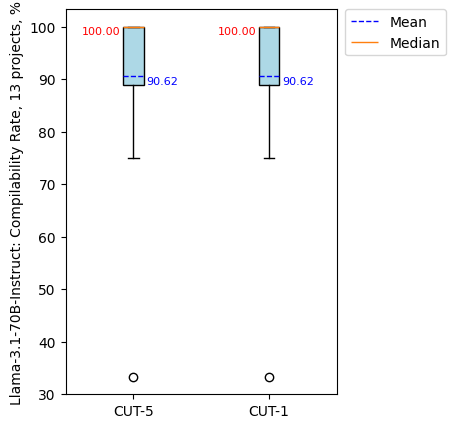

In [ ]:
#######################################################
# Draw boxplots for the line coverage of both prompts #
#######################################################

# prompt_A_name = prettify_prompt_name(prompt_id_A)
# prompt_B_name = prettify_prompt_name(prompt_id_B)

projects_cnt = compilability_rate_mean_merged.shape[0]

print(f"Projects: {projects_cnt}")

bp = build_comparison_boxplot(
    dataset_A=round(100 * compilability_rate_mean_merged[[f'compilability_rate_{prompt_id_A}']], 2).to_numpy().flatten().tolist(),
    dataset_B=round(100 * compilability_rate_mean_merged[[f'compilability_rate_{prompt_id_B}']], 2).to_numpy().flatten().tolist(),
    prompt_type_A=prompt_id_A,
    prompt_type_B=prompt_id_B,
    ylabel=f'{model}: Compilability Rate, {projects_cnt} projects, %',
    # title=f'Compilability Rate between {prompt_A_name} and {prompt_B_name} Prompts'
)